## Import and data extarct

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplot, figure
from pandas import DataFrame

## filters rain event date by max threshold

### filters all the events and print the file name, the time of max discharge and the max discharge

In [2]:
directory = r'C:\Users\raznu\Development\RESEARCH\Raanana\data\discharge/'

### SUBMIT DISCHARGE THRESHOLDS CMS UNITS
TOP_THRESHOLD = 99999
LOWER_THRESHOLD = 6.5
discharge_max_values_l = []
time_maxdis_l = []
for filename in os.listdir(directory):
    if filename.endswith("hydrograph.csv"):
        df_event = pd.read_csv (directory + filename)
        max_vals = df_event['dischrge_cms'].max()
        if max_vals > LOWER_THRESHOLD and max_vals < TOP_THRESHOLD :
            discharge_max_values_l.append(max_vals)
            time_of_maxdis = df_event['date_and_time'][df_event['dischrge_cms'].idxmax()]
            time_maxdis_l.append(time_of_maxdis)
#             print('file name: ' + filename , 'time of max discharge: ' + time_of_maxdis , max_vals , '[cms]')
num_of_events = len(time_maxdis_l)
# print('number of events within the thresholds: ' , num_of_events )


#### df format

In [3]:
max_dischrage_df = pd.DataFrame({'time': time_maxdis_l, 'max_dischrge_[cms]': discharge_max_values_l})
max_dischrage_df

,time,max_dischrge_[cms]
0,11/12/1983 02:49:00,6.60
1,10/11/1984 11:01:00,6.81
2,12/12/1984 11:58:30,8.81
3,05/02/1986 13:41:29,7.38
4,07/04/1986 03:41:30,8.89
...,...,...
111,01/04/2019 06:01:59,10.31
112,13/12/2019 00:58:05,26.74
113,27/12/2019 10:40:05,29.07
114,10/01/2020 4:20:00,7.39


In [4]:
## mean events per year:
max_dischrage_df['time'] = pd.to_datetime(max_dischrage_df['time'])
max_dischrage_df['year'] = max_dischrage_df['time'].dt.year
events_per_year = max_dischrage_df.groupby('year').size()
average_events_per_year = events_per_year.mean()
events_per_year

year
1983     1
1984     2
1986     5
1987     3
1988     4
1992     1
1994     8
1995     2
1996     9
1997     4
1998     4
1999     4
2000     8
2001     1
2003     3
2004     9
2005     7
2006     3
2009     1
2012     1
2013     1
2014     1
2015     6
2016     7
2017     2
2018    12
2019     5
2020     2
dtype: int64

## selects the event after date threshold


### Note!!!! format may do some troubles

#### mm-dd may switch

In [5]:
max_dischrage_df = pd.DataFrame({'time' : time_maxdis_l, 'max_dischrge_[cms]' : discharge_max_values_l})
max_dischrage_df['time'] = pd.to_datetime(max_dischrage_df['time'])
max_dischrage_df.set_index('time',inplace = True)
# print(max_dischrage_df)

# Set the date you want to use as the thrdeshold for selecting rows
threshold_date = pd.to_datetime('2010-10-30')
high_dischrage_and_dates_raanana_df = max_dischrage_df.loc[max_dischrage_df.index > threshold_date]
print(len(high_dischrage_and_dates_raanana_df))

# Save the DataFrame to a CSV file
high_dischrage_and_dates_raanana_df.to_csv(r'C:\Users\raznu\Development\RESEARCH\Raanana\data/high_dischrage_and_dates_raanana_bigger_than6.5cms.csv')

37


In [9]:
high_dischrage_and_dates_raanana_df.shape

(37, 1)

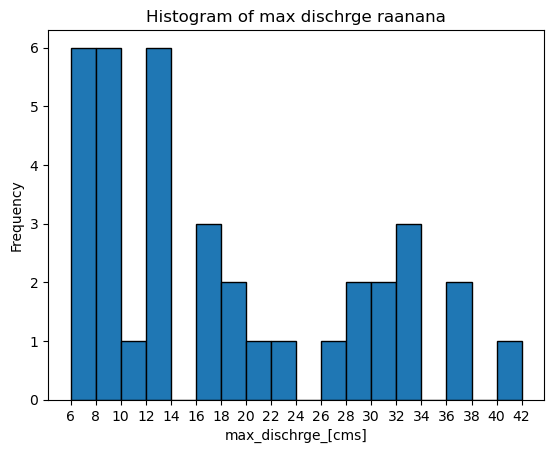

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'high_dischrage_and_dates_raanana_df' is your DataFrame containing the data
# and 'high_discharge' is the column you want to create a histogram for

# Create the histogram
plt.hist(high_dischrage_and_dates_raanana_df['max_dischrge_[cms]'], bins=range(int(min(high_dischrage_and_dates_raanana_df['max_dischrge_[cms]'])),
                                                                     int(max(high_dischrage_and_dates_raanana_df['max_dischrge_[cms]'])) + 2, 2),
                                                                     edgecolor='black')

# Set x-axis labels
plt.xticks(range(int(min(high_dischrage_and_dates_raanana_df['max_dischrge_[cms]'])),
                 int(max(high_dischrage_and_dates_raanana_df['max_dischrge_[cms]'])) + 2, 2))

# Add labels and title
plt.xlabel('max_dischrge_[cms]')
plt.ylabel('Frequency')
plt.title('Histogram of max dischrge raanana')

# Display the histogram
plt.show()